# <p style="font-family: Cambria; text-align: center; font-size: 44px;">IV. PREDICTIVE ANALYSIS</p>



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score,
    average_precision_score, RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)

df = pd.read_csv("Team2_PythonPioneers_Cardiac_Cleaned_Data.csv")
print("Dataset shape:", df.shape)
print("Unique patients:", df["inpatient_number"].nunique())

Dataset shape: (2008, 210)
Unique patients: 2008


<p style="font-family: Cambria; font-size: 16px;"><b>Shared helper functions and chart colours</b></p>

In [2]:
def build_logistic_model(features, categorical_features):

    # Keep only categorical columns included in the feature list
    categorical_features = [
        col for col in categorical_features
        if col in features
    ]

    # Remaining columns are treated as numeric
    numeric_features = [
        col for col in features
        if col not in categorical_features
    ]

    transformers = []

    # -----------------------------
    # Numeric preprocessing
    # -----------------------------
    if numeric_features:

        numeric_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            )
        ])

        transformers.append(
            (
                "numeric",
                numeric_pipeline,
                numeric_features
            )
        )

    # -----------------------------
    # Categorical preprocessing
    # -----------------------------
    if categorical_features:

        categorical_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first"
                )
            )
        ])

        transformers.append(
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        )

    # -----------------------------
    # Preprocessor
    # -----------------------------
    preprocessor = ColumnTransformer(
        transformers=transformers
    )

    # -----------------------------
    # Final ML pipeline
    # -----------------------------
    model = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=42
            )
        )
    ])

    return model


print("\nPredictive analysis setup completed successfully!")


Predictive analysis setup completed successfully!


In [3]:
cols = ["#6daa9f", "#774571", "#6daa9f", "#774571"]   # palette used in Q9-Q12

# ---------- Same colour system as the descriptive notebook ----------
INK, MUTED, GRID = "#1f1f1f", "#6b6b6b", "#e6e6e6"
BLUE    = "#2a78d6"   # single series, and "Readmission"
ORANGE  = "#eb6834"   # second series, and "Death"
REF     = "#d03b3b"   # reference lines only (coin-toss line, cut-offs)
NEUTRAL = "#b8b6b0"
RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281", "#0d366b"]
def ramp(n):
    """n evenly spaced steps from the blue ramp (light -> dark)."""
    return [RAMP[i] for i in np.linspace(0, len(RAMP) - 1, n).round().astype(int)]

plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#bdbdbd", "axes.labelcolor": INK, "xtick.color": MUTED,
                     "ytick.color": MUTED, "axes.titleweight": "bold", "axes.titlesize": 12,
                     "font.size": 10, "legend.frameon": False})

def label_bars(ax, fmt="{:.1f}%"):
    for c in ax.containers:
        ax.bar_label(c, labels=[fmt.format(v) for v in c.datavalues], padding=3, fontsize=9, color=INK)

def suptitle(fig, text):
    fig.suptitle(text, fontsize=14, fontweight="bold", x=0.06, ha="left", y=1.02)

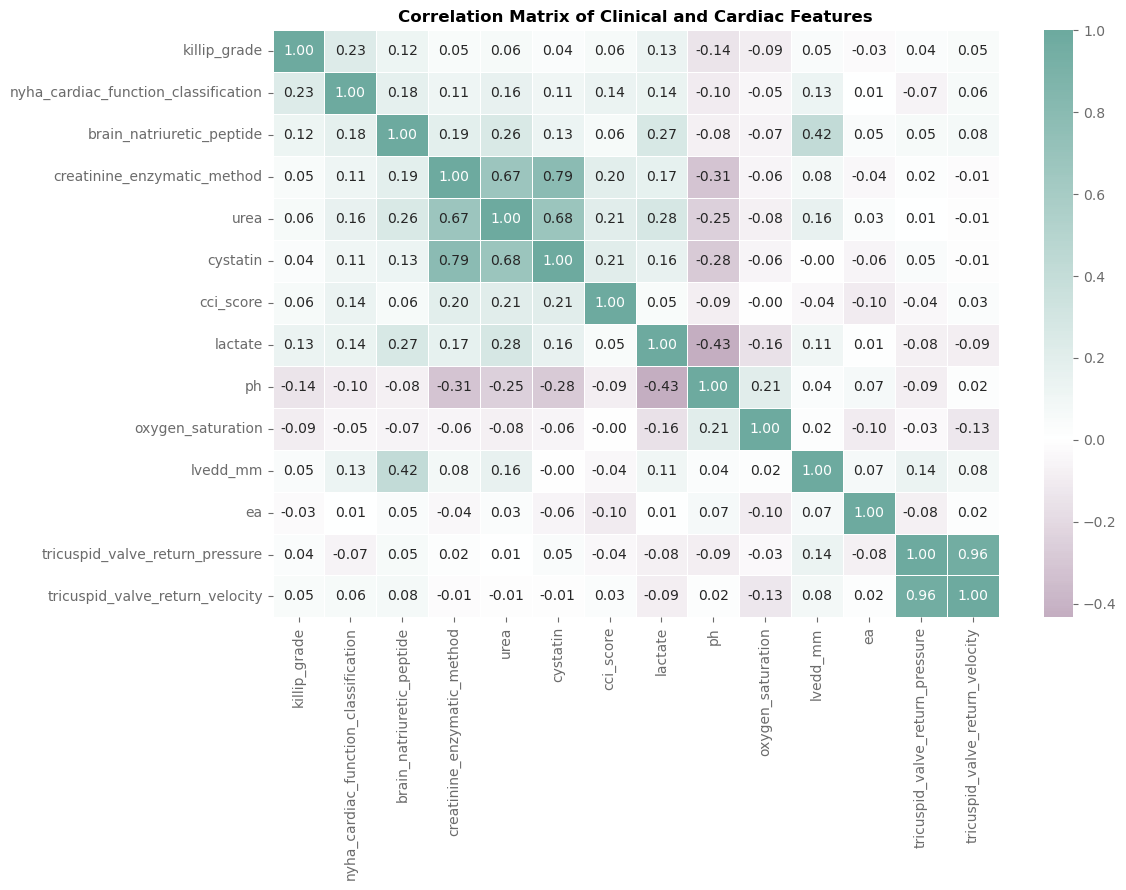

In [4]:
# Examining a Correlation Matrix of All Features

# Admission-time clinical and cardiac features
corr_features = [
    "killip_grade",
    "nyha_cardiac_function_classification",
    "brain_natriuretic_peptide",
    "creatinine_enzymatic_method",
    "urea",
    "cystatin",
    "cci_score",
    "lactate",
    "ph",
    "oxygen_saturation",
    "lvedd_mm",
    "ea",
    "tricuspid_valve_return_pressure",
    "tricuspid_valve_return_velocity"
]

corr_data = df[corr_features].apply(pd.to_numeric, errors="coerce").corr()

cmap = LinearSegmentedColormap.from_list(
    "custom",
    ["#774571", "white", "#6daa9f"]
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_data,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Clinical and Cardiac Features")
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The correlation matrix shows the strength and direction of relationships among the selected clinical and cardiac features. Most features have weak-to-moderate correlations, indicating that they capture different aspects of patient condition. Some stronger relationships can be observed among related cardiac and renal measurements, suggesting overlapping clinical information. Overall, the matrix helps identify related variables and potential multicollinearity before building predictive models.</i></b>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q1. Can demographic characteristics such as age, gender, weight, height, BMI, and occupation be used to predict the risk of in-hospital mortality among patients with heart failure?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns Used</b></p>
<p style="font-family: Cambria; font-size: 16px;"><code>agecat</code>, <code>gender</code>, <code>weight</code>, <code>height</code>, <code>bmi</code>, <code>occupation</code>, <code>outcome_during_hospitalization</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
Demographic characteristics may contain information related to mortality risk, but they do not directly measure heart-failure severity. This question tests whether age group, gender, body measurements and occupation can distinguish patients who die during hospitalization from those who survive. Because in-hospital mortality is rare, a class-balanced Logistic Regression model is used and performance is interpreted using ROC-AUC, recall, precision, F1-score and the confusion matrix rather than accuracy alone.
</i></b></p>


In [5]:
df["in_hospital_death"] = (df["outcome_during_hospitalization"] == "Dead").astype(int)

features_q1 = ["agecat", "gender", "weight", "height", "bmi", "occupation"]
X1 = df[features_q1]
y1 = df["in_hospital_death"]

num1 = ["weight", "height", "bmi"]
cat1 = ["agecat", "gender", "occupation"]

prep1 = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num1),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat1)
])

model_q1 = Pipeline([
    ("preprocessor", prep1),
    ("model", LogisticRegression(class_weight="balanced", max_iter=2000))
])

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.30, random_state=42, stratify=y1
)

model_q1.fit(X1_train, y1_train)
pred1 = model_q1.predict(X1_test)
prob1 = model_q1.predict_proba(X1_test)[:, 1]
auc1 = roc_auc_score(y1_test, prob1)

print("In-hospital deaths:", int(y1.sum()), "of", len(y1))
print(classification_report(y1_test, pred1, zero_division=0))
print("ROC-AUC:", round(auc1, 3))
print("Confusion Matrix:\n", confusion_matrix(y1_test, pred1))

In-hospital deaths: 11 of 2008
              precision    recall  f1-score   support

           0       1.00      0.71      0.83       600
           1       0.02      1.00      0.03         3

    accuracy                           0.71       603
   macro avg       0.51      0.86      0.43       603
weighted avg       1.00      0.71      0.83       603

ROC-AUC: 0.91
Confusion Matrix:
 [[428 172]
 [  0   3]]


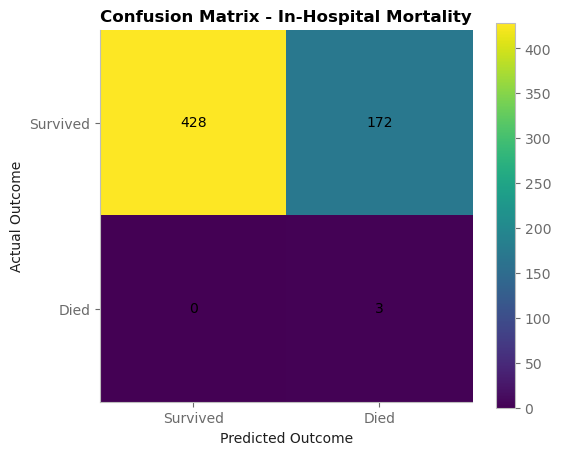

In [6]:
# Confusion Matrix Heatmap
cm1 = confusion_matrix(y1_test, pred1)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm1)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Survived", "Died"])
ax.set_yticklabels(["Survived", "Died"])
ax.set_xlabel("Predicted Outcome")
ax.set_ylabel("Actual Outcome")
ax.set_title("Confusion Matrix - In-Hospital Mortality")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm1[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
The confusion matrix shows that the demographic model correctly identified all 3 in-hospital deaths in the test set, but it also incorrectly classified 172 surviving patients as deaths. Although the model achieved a ROC-AUC of 0.910 and mortality recall of 1.00, mortality precision was only 0.02. This means the model was sensitive to the very small death group but generated many false-positive alerts. Because only 11 of 2,008 patients died during hospitalization, demographic characteristics alone should be treated as exploratory predictors and are not sufficient as a reliable standalone mortality model.
</i></b></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q2. Can demographic and baseline clinical characteristics be used to predict the risk of 28-day mortality among patients with heart failure?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns Used</b></p>
<p style="font-family: Cambria; font-size: 16px;"><code>agecat</code>, <code>gender</code>, <code>bmi</code>, <code>admission_way</code>, <code>nyha_cardiac_function_classification</code>, <code>killip_grade</code>, <code>lvef</code>, <code>systolic_blood_pressure</code>, <code>pulse</code>, <code>cci_score</code>, <code>death_within_28_days</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
Twenty-eight-day mortality reflects short-term risk after hospitalization. Demographics alone may not capture the patient's clinical condition, so this model adds admission type, cardiac severity, LVEF, systolic blood pressure, pulse and comorbidity burden. The objective is to determine whether this combined baseline profile can distinguish patients who die within 28 days from those who survive.
</i></b></p>


In [7]:
features_q2 = [
    "agecat", "gender", "bmi", "admission_way",
    "nyha_cardiac_function_classification", "killip_grade",
    "lvef", "systolic_blood_pressure", "pulse", "cci_score"
]
X2 = df[features_q2]
y2 = df["death_within_28_days"]

num2 = ["bmi", "nyha_cardiac_function_classification", "killip_grade",
        "lvef", "systolic_blood_pressure", "pulse", "cci_score"]
cat2 = ["agecat", "gender", "admission_way"]

prep2 = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num2),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat2)
])

model_q2 = Pipeline([
    ("preprocessor", prep2),
    ("model", LogisticRegression(class_weight="balanced", max_iter=2000))
])

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.30, random_state=42, stratify=y2
)

model_q2.fit(X2_train, y2_train)
pred2 = model_q2.predict(X2_test)
prob2 = model_q2.predict_proba(X2_test)[:, 1]
auc2 = roc_auc_score(y2_test, prob2)

print("28-day deaths:", int(y2.sum()), "of", len(y2))
print(classification_report(y2_test, pred2, zero_division=0))
print("ROC-AUC:", round(auc2, 3))
print("Confusion Matrix:\n", confusion_matrix(y2_test, pred2))

28-day deaths: 37 of 2008
              precision    recall  f1-score   support

           0       0.99      0.82      0.89       592
           1       0.05      0.55      0.10        11

    accuracy                           0.81       603
   macro avg       0.52      0.68      0.49       603
weighted avg       0.97      0.81      0.88       603

ROC-AUC: 0.771
Confusion Matrix:
 [[483 109]
 [  5   6]]


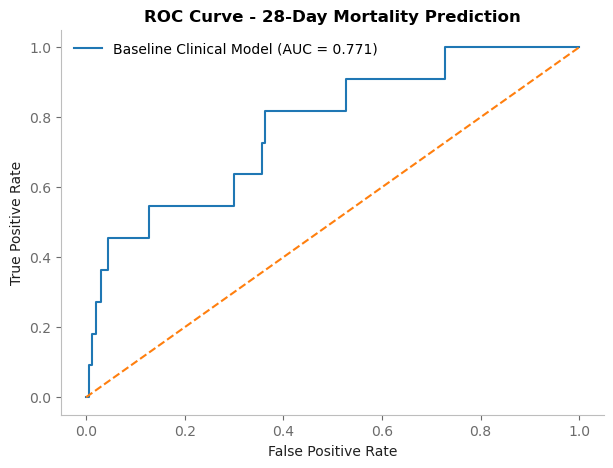

In [8]:
# ROC Curve
fpr2, tpr2, _ = roc_curve(y2_test, prob2)

plt.figure(figsize=(7, 5))
plt.plot(fpr2, tpr2, label=f"Baseline Clinical Model (AUC = {auc2:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 28-Day Mortality Prediction")
plt.legend()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
The ROC curve shows that the combined demographic and baseline clinical model achieved a ROC-AUC of 0.771 for predicting 28-day mortality, indicating useful but not strong discrimination between patients who died and those who survived. The model correctly identified 6 of the 11 deaths in the test set, giving a mortality recall of 0.55, but precision was only 0.05 because many surviving patients were also classified as high risk. These results suggest that demographics, cardiac severity, vital signs and comorbidity together provide some predictive information for short-term mortality, but the small number of deaths means the model should be interpreted cautiously.
</i></b></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q3. Can NYHA functional class and Killip grade together predict 28-day mortality better than either heart-failure severity measure alone?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns Used</b></p>
<p style="font-family: Cambria; font-size: 16px;"><code>nyha_cardiac_function_classification</code>, <code>killip_grade</code>, <code>death_within_28_days</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
NYHA functional class and Killip grade measure different aspects of heart-failure severity. Three predictive models are compared: NYHA alone, Killip alone, and NYHA plus Killip. All models use the same train/test split so their ROC-AUC values can be compared fairly. If the combined model performs better, it suggests that the two severity measures provide complementary predictive information.
</i></b></p>


In [9]:
y3 = df["death_within_28_days"]

train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.30, random_state=42, stratify=y3
)

def severity_model(features):
    X = df[features]
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y3.iloc[train_idx], y3.iloc[test_idx]

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", max_iter=2000))
    ])
    model.fit(X_train, y_train)
    probability = model.predict_proba(X_test)[:, 1]
    return model, probability, roc_auc_score(y_test, probability)

nyha_model, nyha_prob, nyha_auc = severity_model(
    ["nyha_cardiac_function_classification"]
)
killip_model, killip_prob, killip_auc = severity_model(
    ["killip_grade"]
)
combined_model, combined_prob, combined_auc = severity_model(
    ["nyha_cardiac_function_classification", "killip_grade"]
)

results_q3 = pd.DataFrame({
    "Model": ["NYHA", "Killip", "NYHA + Killip"],
    "ROC-AUC": [nyha_auc, killip_auc, combined_auc]
})
display(results_q3.round(3))

,Model,ROC-AUC
0,NYHA,0.694
1,Killip,0.772
2,NYHA + Killip,0.807


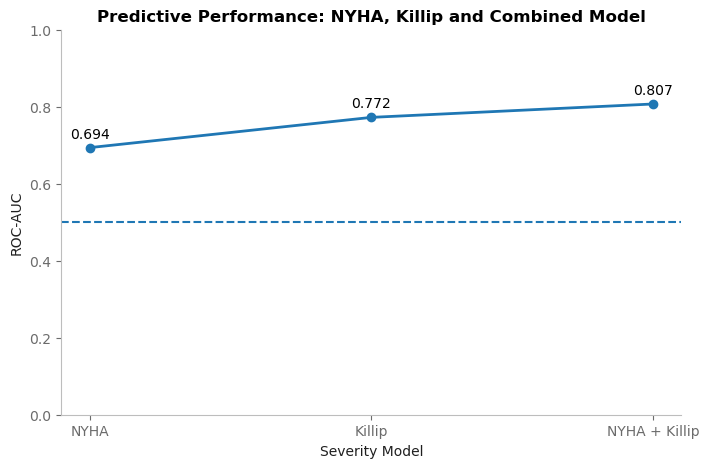

In [10]:
# Line chart comparing the three severity models
plt.figure(figsize=(8, 5))
plt.plot(
    results_q3["Model"],
    results_q3["ROC-AUC"],
    marker="o",
    linewidth=2
)
plt.axhline(0.5, linestyle="--")
plt.ylabel("ROC-AUC")
plt.xlabel("Severity Model")
plt.title("Predictive Performance: NYHA, Killip and Combined Model")
plt.ylim(0, 1)

for x, y in zip(results_q3["Model"], results_q3["ROC-AUC"]):
    plt.text(x, y + 0.025, f"{y:.3f}", ha="center")

plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
The model-comparison chart shows that NYHA alone produced a ROC-AUC of 0.694, Killip grade alone produced 0.772, and the combined NYHA + Killip model produced the highest ROC-AUC at 0.807. The combined model improved AUC by 0.113 compared with NYHA alone and by 0.035 compared with Killip alone. This suggests that NYHA and Killip provide complementary information for predicting 28-day mortality, with the combined severity model showing the strongest discrimination of the three in this test split.
</i></b></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q4. Can renal-function markers predict 6-month mortality and 6-month readmission in patients with heart failure?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns Used</b></p>
<p style="font-family: Cambria; font-size: 16px;"><code>creatinine_enzymatic_method</code>, <code>urea</code>, <code>uric_acid</code>, <code>glomerular_filtration_rate</code>, <code>cystatin</code>, <code>acute_renal_failure</code>, <code>moderate_to_severe_chronic_kidney_disease</code>, <code>death_within_6_months</code>, <code>re_admission_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
Kidney dysfunction commonly accompanies severe heart failure and may provide prognostic information. Creatinine, urea, uric acid, GFR and cystatin represent different aspects of renal function, while acute renal failure and moderate-to-severe chronic kidney disease represent diagnosed renal impairment. Separate prediction models are built for 6-month mortality and 6-month readmission to determine whether a renal-only profile can discriminate both outcomes.
</i></b></p>


In [11]:
renal_features = [
    "creatinine_enzymatic_method", "urea", "uric_acid",
    "glomerular_filtration_rate", "cystatin",
    "acute_renal_failure", "moderate_to_severe_chronic_kidney_disease"
]

def renal_model(outcome):
    X = df[renal_features]
    y = df[outcome]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=42, stratify=y
    )

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", max_iter=2000))
    ])

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, prob)
    return model, y_test, pred, prob, auc

mort_model4, mort_y4, mort_pred4, mort_prob4, mort_auc4 = renal_model(
    "death_within_6_months"
)
readm_model4, readm_y4, readm_pred4, readm_prob4, readm_auc4 = renal_model(
    "re_admission_within_6_months"
)

results_q4 = pd.DataFrame({
    "Outcome": ["6-Month Mortality", "6-Month Readmission"],
    "ROC-AUC": [mort_auc4, readm_auc4]
})
display(results_q4.round(3))

print("\n6-Month Mortality")
print(classification_report(mort_y4, mort_pred4, zero_division=0))
print("\n6-Month Readmission")
print(classification_report(readm_y4, readm_pred4, zero_division=0))

,Outcome,ROC-AUC
0,6-Month Mortality,0.586
1,6-Month Readmission,0.576



6-Month Mortality
              precision    recall  f1-score   support

           0       0.98      0.83      0.90       586
           1       0.07      0.41      0.12        17

    accuracy                           0.82       603
   macro avg       0.52      0.62      0.51       603
weighted avg       0.95      0.82      0.88       603


6-Month Readmission
              precision    recall  f1-score   support

           0       0.66      0.64      0.65       371
           1       0.45      0.47      0.46       232

    accuracy                           0.58       603
   macro avg       0.56      0.56      0.56       603
weighted avg       0.58      0.58      0.58       603



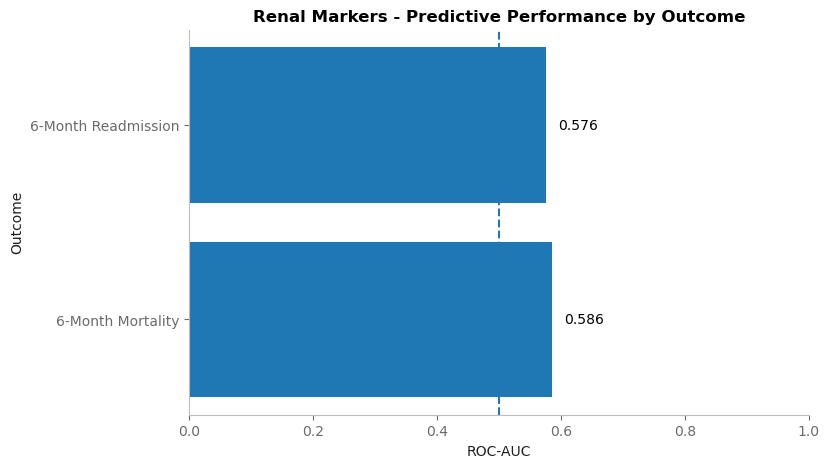

In [12]:
# Horizontal bar chart comparing renal-model performance
plt.figure(figsize=(8, 5))
plt.barh(results_q4["Outcome"], results_q4["ROC-AUC"])
plt.axvline(0.5, linestyle="--")
plt.xlabel("ROC-AUC")
plt.ylabel("Outcome")
plt.title("Renal Markers - Predictive Performance by Outcome")
plt.xlim(0, 1)

for i, value in enumerate(results_q4["ROC-AUC"]):
    plt.text(value + 0.02, i, f"{value:.3f}", va="center")

plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b><i>
The horizontal bar chart shows that renal-function markers produced a ROC-AUC of 0.586 for 6-month mortality and 0.576 for 6-month readmission. Both values are only slightly above the 0.50 reference level, indicating weak predictive discrimination when renal markers are used alone. The mortality model performed only marginally better than the readmission model, with an AUC difference of 0.010. These results suggest that renal markers may contribute useful risk information, but they are not strong standalone predictors and would be better combined with cardiac severity, biomarkers, comorbidities and other clinical characteristics.
</i></b></p>